In [0]:
# ===============================
# Import Required Libraries
# ===============================

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.sql.window import Window

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("Set2")

pd.set_option("display.max_columns", None)

In [0]:
from pyspark.sql.types import *

schema = StructType([
    StructField("main_category", StringType()),
    StructField("title", StringType()),
    StructField("average_rating", DoubleType()),
    StructField("rating_number", LongType()),
    StructField("features", ArrayType(StringType())),
    StructField("description", ArrayType(StringType())),
    StructField("price", DoubleType()),
    StructField("images", ArrayType(MapType(StringType(), StringType()))),
    StructField("videos", ArrayType(MapType(StringType(), StringType()))),
    StructField("store", StringType()),
    StructField("categories", ArrayType(StringType())),
    StructField("details", MapType(StringType(), StringType())),
    StructField("parent_asin", StringType()),
    StructField("bought_together", StringType())
])

meta_df = spark.read.schema(schema).json(
    "/Volumes/project/default/data/meta_Appliances.jsonl"
)

In [0]:
# ==========================================
# Metadata Dataset Overview
# ==========================================

print("=" * 70)
print("Metadata Dataset Overview")
print("=" * 70)

print(f"Total Products : {meta_df.count():,}")
print(f"Total Columns  : {len(meta_df.columns)}")

Metadata Dataset Overview
Total Products : 94,327
Total Columns  : 14


In [0]:
rating_dist = (
    meta_df
    .groupBy("average_rating")
    .count()
    .orderBy("average_rating")
)

rating_pd = rating_dist.toPandas()

rating_pd.head()

,average_rating,count
0,1.0,2766
1,1.1,1
2,1.2,10
3,1.3,39
4,1.4,40


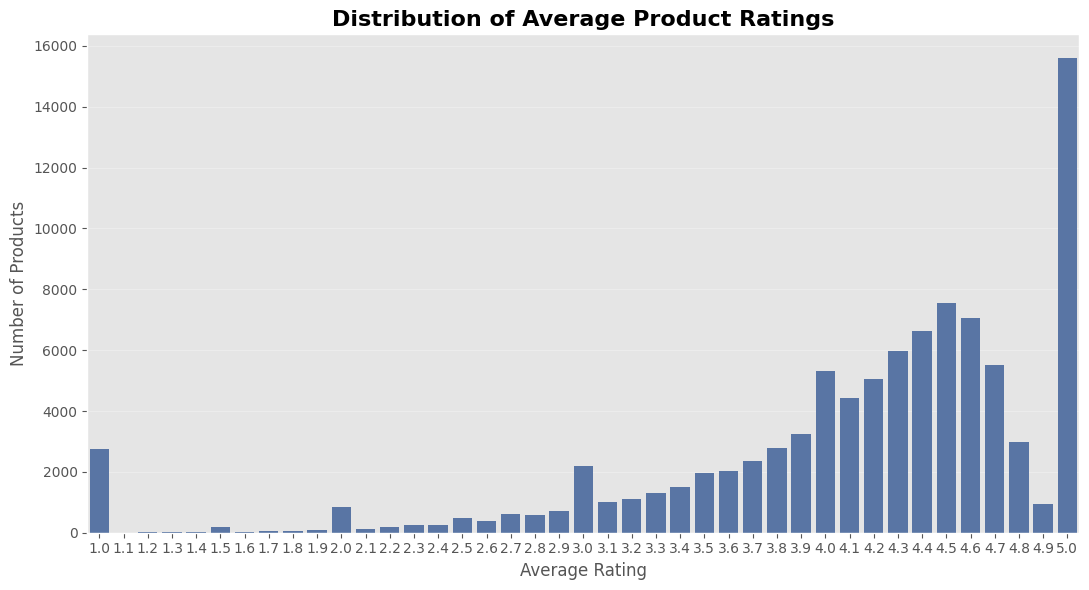

In [0]:
plt.figure(figsize=(11,6))

sns.barplot(
    data=rating_pd,
    x="average_rating",
    y="count",
    color="#4C72B0"
)

plt.title("Distribution of Average Product Ratings", fontsize=16, weight="bold")
plt.xlabel("Average Rating")
plt.ylabel("Number of Products")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [0]:
# ==========================================
# Rating Count Statistics
# ==========================================

display(
    meta_df.select("rating_number").describe()
)

summary,rating_number
count,94327
mean,136.36790102515715
stddev,977.5160999553378
min,1
max,90203


In [0]:
# Calculate 99th percentile
rating_limit = meta_df.approxQuantile("rating_number", [0.99], 0.01)[0]

rating_count_pd = (
    meta_df
    .filter(F.col("rating_number") <= rating_limit)
    .select("rating_number")
    .toPandas()
)

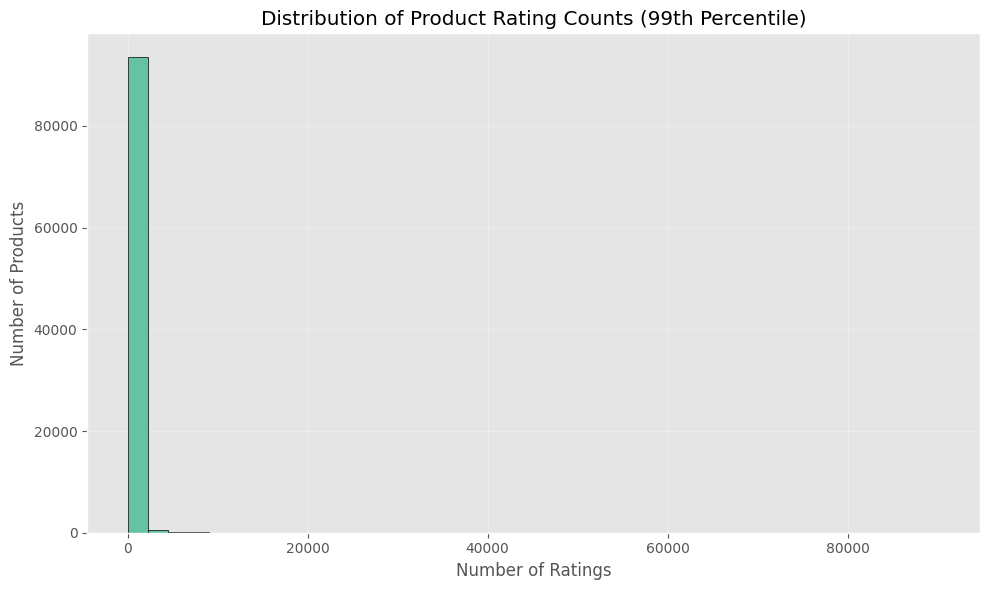

In [0]:
plt.figure(figsize=(10,6))

plt.hist(
    rating_count_pd["rating_number"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Product Rating Counts (99th Percentile)")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Products")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

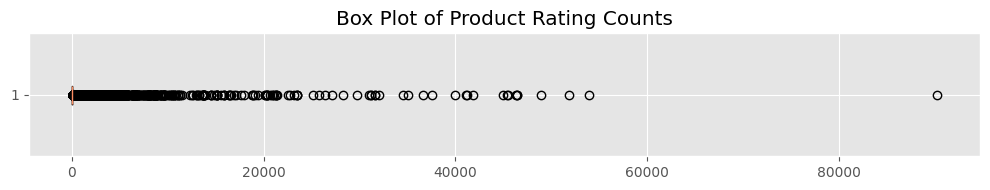

In [0]:
plt.figure(figsize=(10,2))

plt.boxplot(
    rating_count_pd["rating_number"],
    vert=False
)

plt.title("Box Plot of Product Rating Counts")

plt.tight_layout()
plt.show()

In [0]:
# ==========================================
# Top 15 Stores by Product Count
# ==========================================

store_df = (
    meta_df
    .filter(
        (F.col("store").isNotNull()) &
        (F.trim(F.col("store")) != "")
    )
    .groupBy("store")
    .count()
    .orderBy(F.desc("count"))
    .limit(15)
)

store_pd = store_df.toPandas()

store_pd.head()

,store,count
0,Whirlpool,8687
1,GE,4994
2,FRIGIDAIRE,2912
3,SAMSUNG,2245
4,LG,1876


/home/spark-c48d9592-2db9-41b7-9617-12/.ipykernel/316/command-8884370607422063-3226138463:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


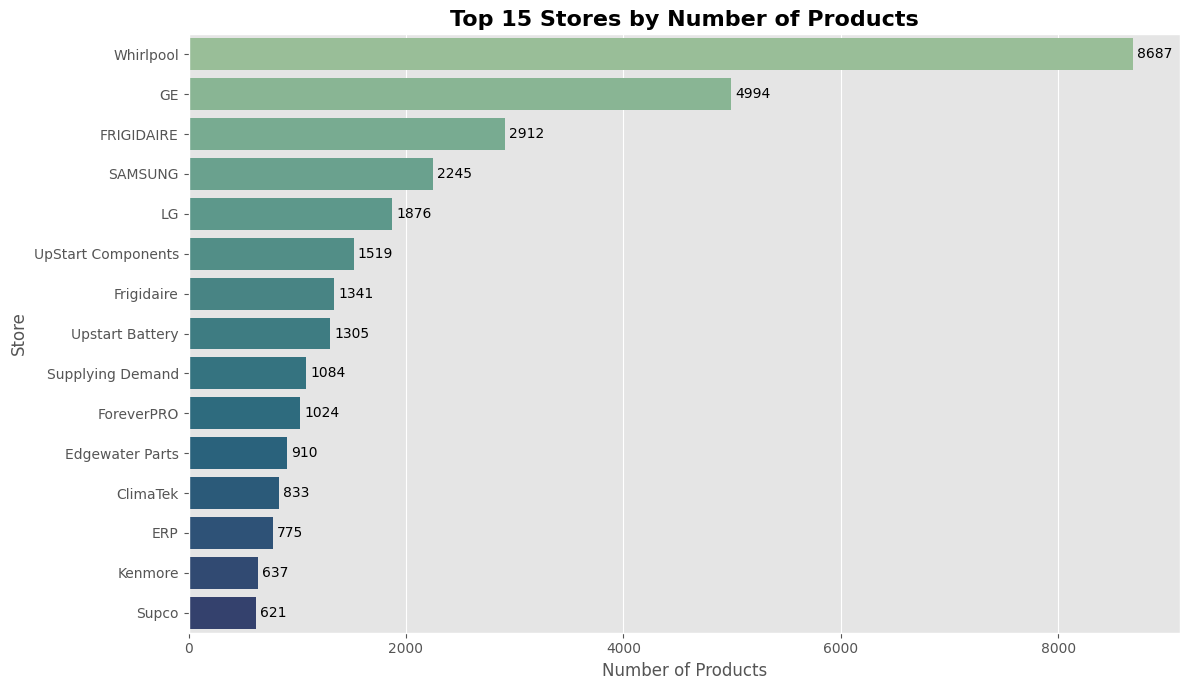

In [0]:
plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=store_pd,
    y="store",
    x="count",
    palette="crest"
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title(
    "Top 15 Stores by Number of Products",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Number of Products")
plt.ylabel("Store")

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Top Product Categories
# ==========================================

category_df = (
    meta_df
    .withColumn("category", F.explode("categories"))
    .filter(F.col("category").isNotNull())
    .groupBy("category")
    .count()
    .orderBy(F.desc("count"))
    .limit(15)
)

category_pd = category_df.toPandas()

category_pd.head()

,category,count
0,Appliances,85384
1,Parts & Accessories,71321
2,Dryer Parts & Accessories,15354
3,Refrigerator Parts & Accessories,14246
4,Replacement Parts,13785


/home/spark-c48d9592-2db9-41b7-9617-12/.ipykernel/316/command-8884370607422077-790392801:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


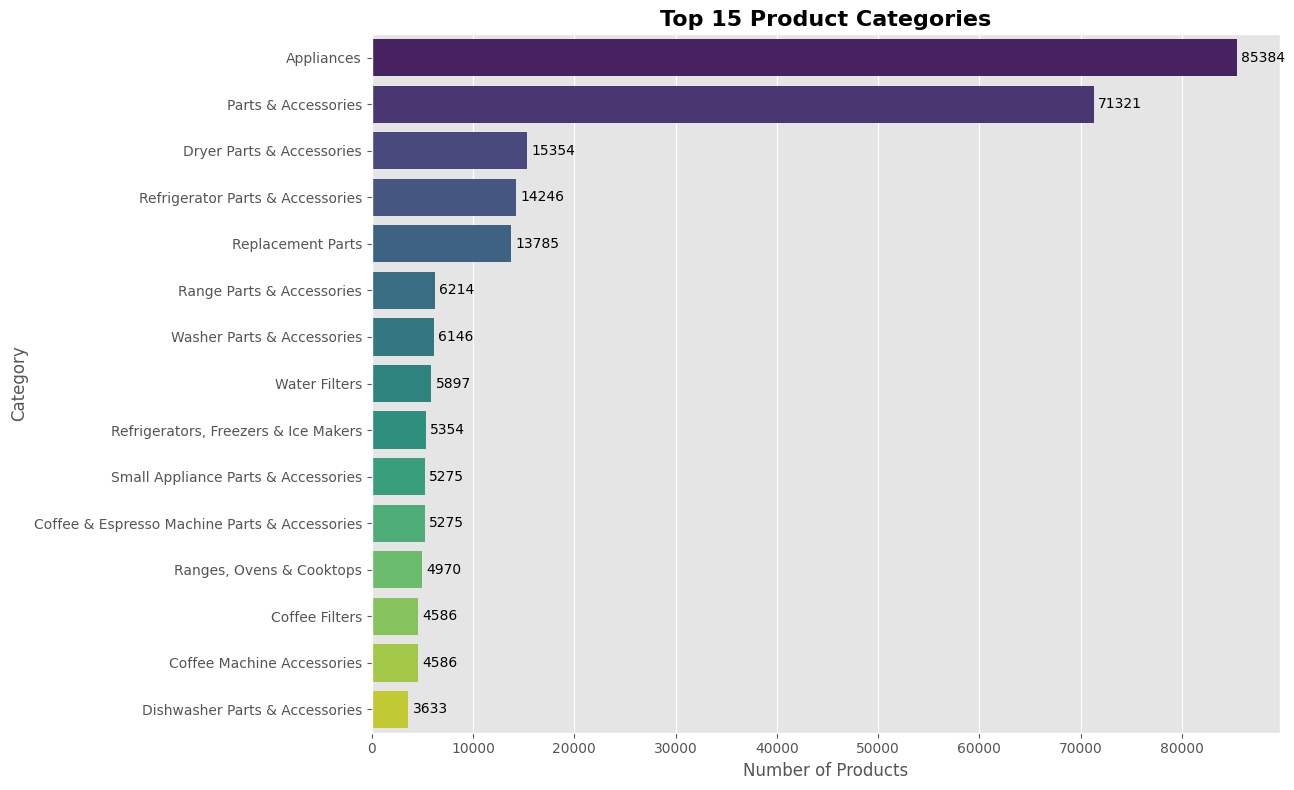

In [0]:
plt.figure(figsize=(13,8))

ax = sns.barplot(
    data=category_pd,
    y="category",
    x="count",
    palette="viridis"
)

# Value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title(
    "Top 15 Product Categories",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Number of Products")
plt.ylabel("Category")

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Price Summary Statistics
# ==========================================

display(
    meta_df.select("price").describe()
)

summary,price
count,46726
mean,86.47995398707187
stddev,325.31839745756366
min,0.01
max,21095.62


In [0]:
# ==========================================
# Prepare Price Data
# ==========================================

price_limit = meta_df.approxQuantile("price", [0.99], 0.01)[0]

price_pd = (
    meta_df
    .filter(
        (F.col("price").isNotNull()) &
        (F.col("price") > 0) &
        (F.col("price") <= price_limit)
    )
    .select("price")
    .toPandas()
)

price_pd.head()

,price
0,25.07
1,8.99
2,53.68
3,16.52
4,6.29


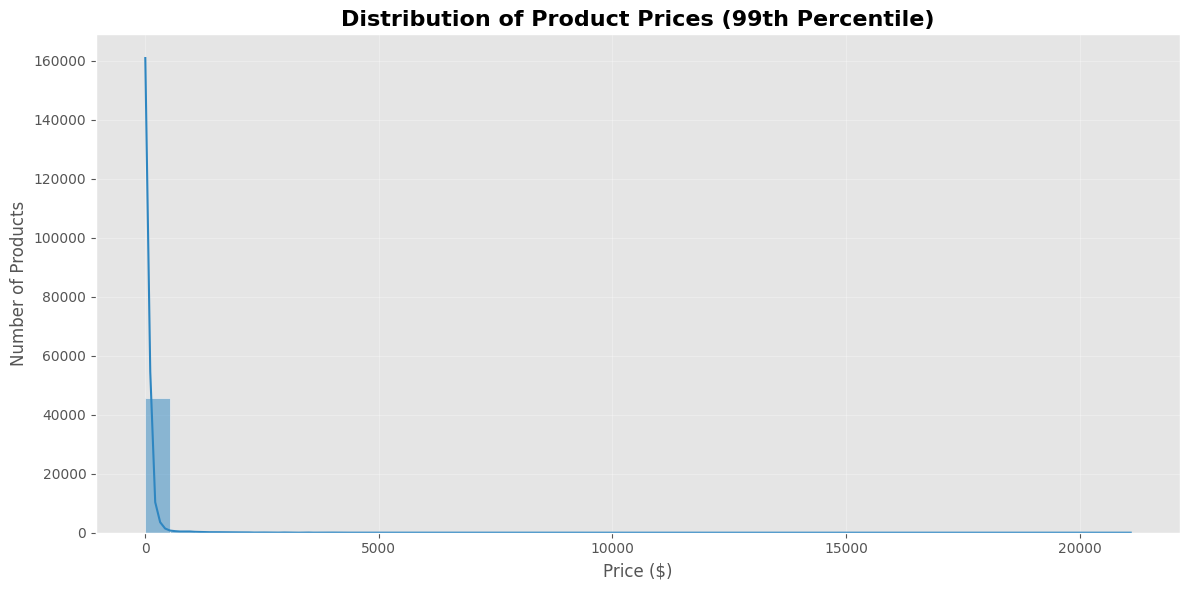

In [0]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=price_pd,
    x="price",
    bins=40,
    kde=True,
    color="#2E86C1"
)

plt.title(
    "Distribution of Product Prices (99th Percentile)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Price ($)")
plt.ylabel("Number of Products")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

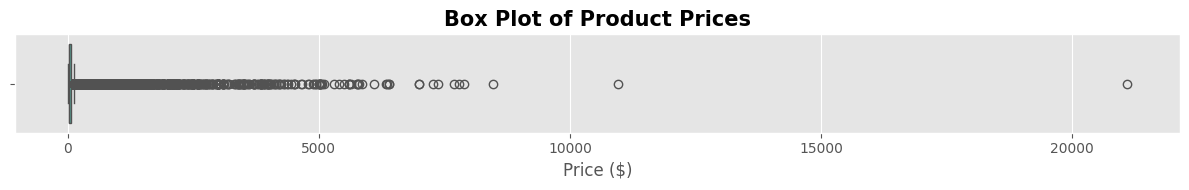

In [0]:
plt.figure(figsize=(12,2))

sns.boxplot(
    x=price_pd["price"],
    color="#48C9B0"
)

plt.title(
    "Box Plot of Product Prices",
    fontsize=15,
    weight="bold"
)

plt.xlabel("Price ($)")

plt.tight_layout()

plt.show()

In [0]:
price_rating = (
    meta_df
    .filter(
        (F.col("price").isNotNull()) &
        (F.col("average_rating").isNotNull()) &
        (F.col("price") > 0) &
        (F.col("price") <= price_limit)
    )
    .select("price", "average_rating")
    .toPandas()
)

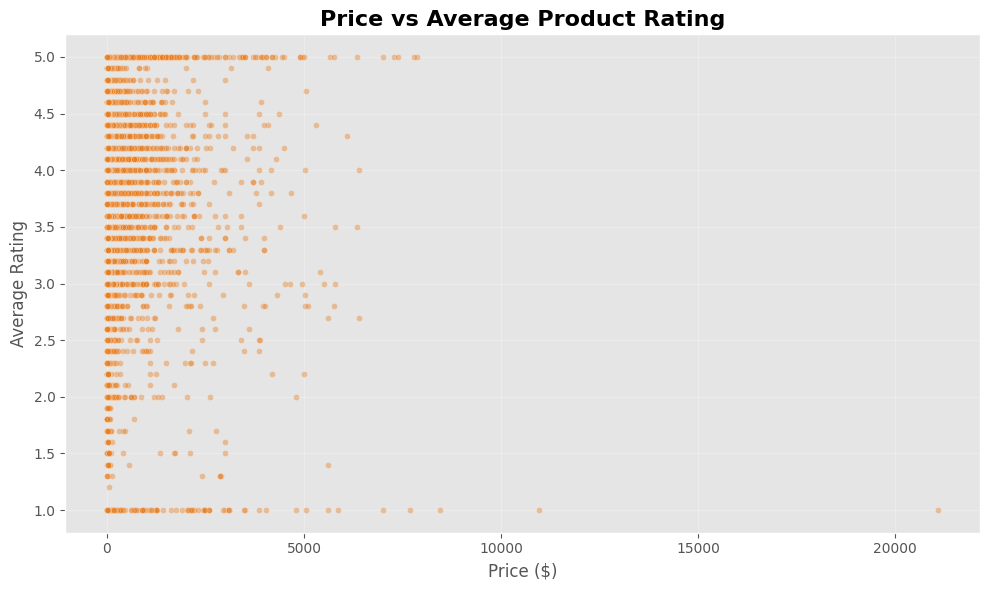

In [0]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=price_rating,
    x="price",
    y="average_rating",
    alpha=0.4,
    s=20,
    color="#E67E22"
)

plt.title(
    "Price vs Average Product Rating",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Price ($)")
plt.ylabel("Average Rating")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Top 10 Highest Rated Products
# ==========================================

top_rated = (
    meta_df
    .filter(
        (F.col("average_rating").isNotNull()) &
        (F.col("rating_number") >= 50)      # Only products with sufficient reviews
    )
    .select(
        "title",
        "store",
        "average_rating",
        "rating_number"
    )
    .orderBy(
        F.desc("average_rating"),
        F.desc("rating_number")
    )
    .limit(10)
)

display(top_rated)

title,store,average_rating,rating_number
"Technivorm #4 Filters (6pk, White)",Technivorm Moccamaster,5.0,51
"Stylish Dishwasher Magnet Clean Dirty Sign - Ideal Clean Dirty Magnet for Dishwasher - Kitchen Organizer and Gadget - Nice Office, Home Farmhouse Decor - Dirty Clean Dishwasher Magnet",ASSURED SIGNS,4.9,4207
"BUNN 8-12 Cup Coffee Filters, 6 each, 100ct",BUNN,4.9,2466
Gravity Falls: The Complete Series - Collector's Edition [DVD],"Jason Ritter (Actor), Kristen Schaal (Actor) Rated: NR Format: DVD",4.9,2445
Chemex Bonded Filter - Natural Square - 100 ct - 2 Pack - Exclusive Packaging,Chemex,4.9,1261
"AuldHome Enamelware Coffee Filter Holder (White, Cone-Shaped), Wall-Mount Vintage Farmhouse Style White Filter Storage Container",AuldHome Design,4.9,1161
Melitta FBA USA Inc 626412#6 Natural Brown Cone Coffee Filters 40 Count - 4 PACK,Melitta,4.9,623
"Melitta Super Premium Coffee Filters, Naturan Brown, No. 4, 100-Count Filters (Pack of 3)",Melitta,4.9,468
"6 X Hario 02 100-Count Coffee Natural Paper Filters, 6-Pack Value Set (Total of 600 Sheets)",Hario,4.9,454
"6 X Hario 02 100-Count Coffee Natural Paper Filters, 6-Pack Value Set (Total of 600 Sheets)",Hario,4.9,451


In [0]:
# ==========================================
# Top 10 Most Reviewed Products
# ==========================================

most_reviewed = (
    meta_df
    .filter(
        F.col("rating_number").isNotNull()
    )
    .select(
        "title",
        "store",
        "rating_number",
        "average_rating"
    )
    .orderBy(
        F.desc("rating_number")
    )
    .limit(10)
)

display(most_reviewed)

title,store,rating_number,average_rating
"everydrop by Whirlpool Ice and Water Refrigerator Filter 1, EDR1RXD1, Single-Pack , Purple",EveryDrop by Whirlpool,90203,4.7
"Linda's Essentials Silicone Stove Gap Covers (2 Pack), Heat Resistant Oven Gap Filler Seals Gaps Between Stovetop and Counter, Easy to Clean (25 Inches, White)",Linda's Essentials,53964,4.3
12 Pack Keurig Filter Replacement by K&J - Compatible with Keurig Coffee Machine (2.0 and older),K&J,51830,4.7
"GE RPWFE Refrigerator Water Filter | Certified to Reduce Lead, Sulfur, and 50+ Other Impurities | Replace Every 6 Months for Best Results | Pack of 2",GE,48905,4.7
"Frigidaire WF3CB Puresource3 Refrigerator Water Filter , White, 1 Count (Pack of 1)",Frigidaire,46447,4.7
"Frigidaire WF3CB Puresource3 Refrigerator Water Filter , White, 1 Count (Pack of 1)",Frigidaire,46397,4.7
"Frigidaire WF3CB Puresource3 Refrigerator Water Filter , White, 1 Count (Pack of 1)",Frigidaire,46301,4.7
"Frigidaire WF3CB Puresource3 Refrigerator Water Filter , White, 1 Count (Pack of 1)",FRIGIDAIRE,45503,4.7
"Frigidaire WF3CB Puresource3 Refrigerator Water Filter , White, 1 Count (Pack of 1)",FRIGIDAIRE,45388,4.7
"SAMSUNG Genuine Filters for Refrigerator Water and Ice, Carbon Block Filtration for Clean, Clear Drinking Water, DA29-00020B-3P, 3 Pack",SAMSUNG,44961,4.7


/home/spark-c48d9592-2db9-41b7-9617-12/.ipykernel/316/command-8884370607422068-3945440750:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


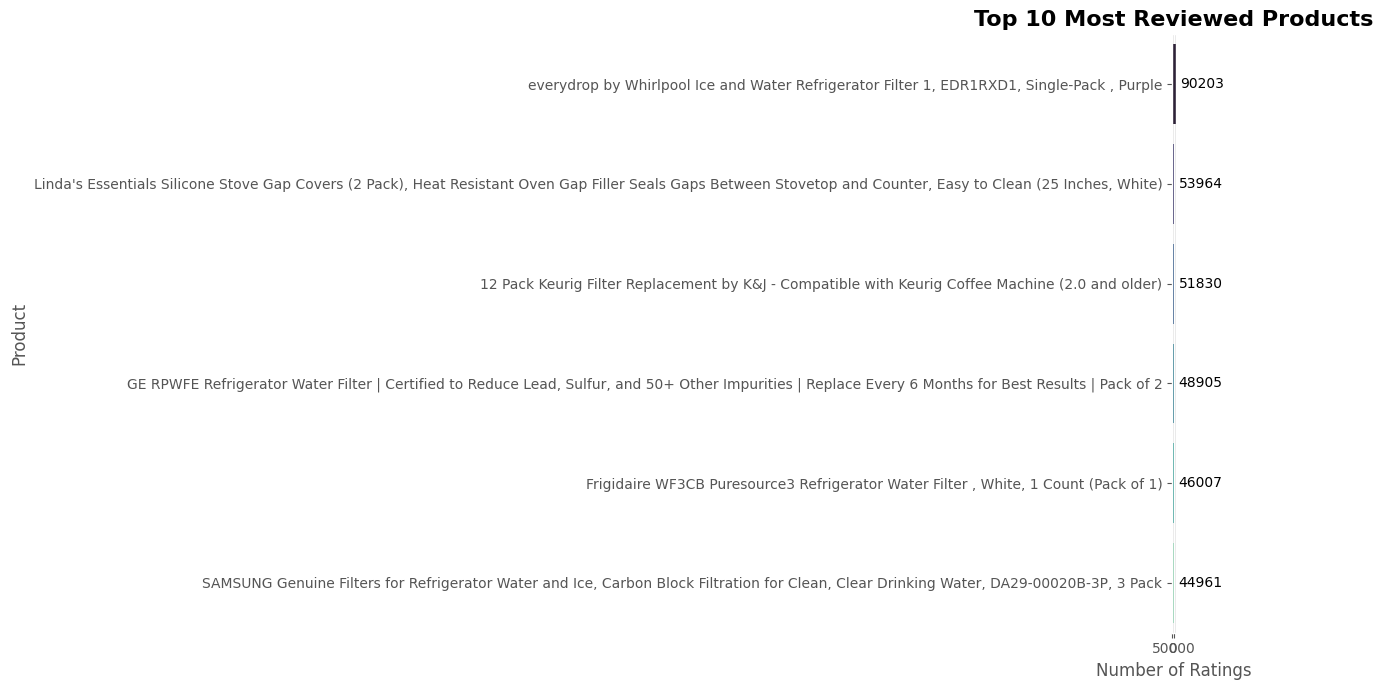

In [0]:
most_reviewed_pd = most_reviewed.toPandas()

plt.figure(figsize=(12,7))

ax = sns.barplot(
    data=most_reviewed_pd,
    y="title",
    x="rating_number",
    palette="mako"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title(
    "Top 10 Most Reviewed Products",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Number of Ratings")
plt.ylabel("Product")

plt.tight_layout()

plt.show()

In [0]:
# ==========================================
# Metadata KPI Summary
# ==========================================

kpi = pd.DataFrame({
    "Metric":[
        "Total Products",
        "Average Rating",
        "Average Price",
        "Average Rating Count"
    ],
    "Value":[
        meta_df.count(),
        round(meta_df.select(F.avg("average_rating")).first()[0],2),
        round(meta_df.select(F.avg("price")).first()[0],2),
        round(meta_df.select(F.avg("rating_number")).first()[0],2)
    ]
})

display(kpi)

Metric,Value
Total Products,94327.0
Average Rating,4.12
Average Price,86.48
Average Rating Count,136.37


# Key Business Insights

### Product Ratings
- Most products maintain average ratings above 4 stars, reflecting high customer satisfaction.

### Product Popularity
- Product popularity is highly concentrated, with a limited number of products receiving the majority of customer ratings.

### Pricing
- Most products fall within the low to medium price range, while premium products form a small segment of the market.

### Store Performance
- A few stores contribute a significant proportion of products, indicating a concentrated marketplace.

### Product Categories
- Certain appliance categories dominate the marketplace, representing key business segments for recommendation systems and inventory planning.